### 	神經網路建模與測試

In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.append('..')  
df = pd.read_csv('../data/cleaned_encoded_data.csv')
df.head(5)
print("Data shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nColumns:")
print(df.columns.tolist())
df.head(5)


Data shape: (46634, 82)

Missing values:
gender                       0
no_show                      0
icd                      36418
appointment_shift            0
age                       8691
                         ...  
appointment_year_2018        0
appointment_year_2019        0
appointment_year_2020        0
appointment_year_2021        0
appointment_year_2022        0
Length: 82, dtype: int64

Columns:
['gender', 'no_show', 'icd', 'appointment_shift', 'age', 'under_12_years_old', 'over_60_years_old', 'patient_needs_companion', 'average_temp_day', 'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before', 'rain_intensity', 'heat_intensity', 'has_icd', 'age_Under 18', 'age_18-30', 'age_31-45', 'age_46-60', 'age_61-75', 'age_75+', 'is_weekend', 'city_BALN. PIÇARRAS', 'city_BLUMENAU', 'city_BOMBINHAS', 'city_CAMBORIU', 'city_ILHOTA', 'city_ITAJAÍ', 'city_ITAPEMA', 'city_LUIZ ALVES', 'city_MONTENEGRO', 'city_NAVEGANTES', 'city_PENHA', 'city_PORTO 

,gender,no_show,icd,appointment_shift,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,...,appointment_month_9,appointment_month_10,appointment_month_11,appointment_month_12,appointment_year_2017,appointment_year_2018,appointment_year_2019,appointment_year_2020,appointment_year_2021,appointment_year_2022
0,1.0,1,NaN,0,NaN,0,0,0,20.75,0.01,...,True,False,False,False,False,False,False,False,True,False
1,1.0,0,NaN,0,NaN,0,0,0,20.75,0.01,...,True,False,False,False,False,False,False,False,True,False
2,0.0,0,NaN,0,NaN,0,0,0,20.75,0.01,...,True,False,False,False,False,False,False,False,True,False
3,0.0,0,NaN,0,NaN,0,0,0,20.75,0.01,...,True,False,False,False,False,False,False,False,True,False
4,1.0,0,I67,0,68.0,0,1,1,20.75,0.01,...,True,False,False,False,False,False,False,False,True,False


In [2]:
y = df['no_show']
X = df.drop(columns=['no_show', 'icd'])

# 4. 檢查特徵類型
print("\nFeature types:")
print(X.dtypes)

# 5. 檢查類別分布
print("\nTarget distribution:")
print(y.value_counts(normalize=True))
df.info()


Feature types:
gender                   float64
appointment_shift          int64
age                      float64
under_12_years_old         int64
over_60_years_old          int64
                          ...   
appointment_year_2018       bool
appointment_year_2019       bool
appointment_year_2020       bool
appointment_year_2021       bool
appointment_year_2022       bool
Length: 80, dtype: object

Target distribution:
no_show
0    0.900073
1    0.099927
Name: proportion, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46634 entries, 0 to 46633
Data columns (total 82 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          46634 non-null  float64
 1   no_show                         46634 non-null  int64  
 2   icd                             10216 non-null  object 
 3   appointment_shift               46634 non-null  int64  
 4   age                     

wandb: Currently logged in as: killabcd6 (killabcd6-northeastern-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


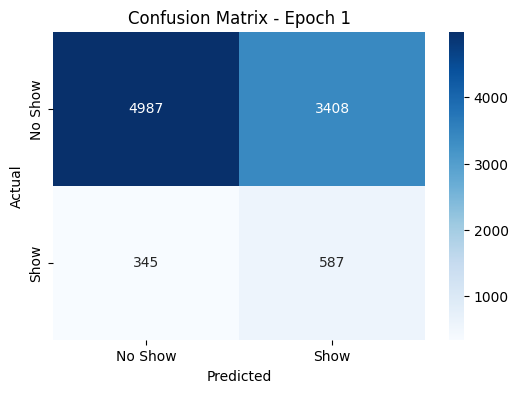

              precision    recall  f1-score   support

         0.0       0.94      0.59      0.73      8395
         1.0       0.15      0.63      0.24       932

    accuracy                           0.60      9327
   macro avg       0.54      0.61      0.48      9327
weighted avg       0.86      0.60      0.68      9327

Epoch 1/10
Train Loss: 1.2235, Val Loss: 0.9075
Val Metrics: {'precision': 0.14693366708385483, 'recall': 0.6298283261802575, 'f1': 0.23827887152425412, 'accuracy': np.float64(0.5976198134448376), 'roc_auc': np.float64(0.6567956350474301), 'true_positives': np.int64(587), 'false_positives': np.int64(3408), 'true_negatives': np.int64(4987), 'false_negatives': np.int64(345)}


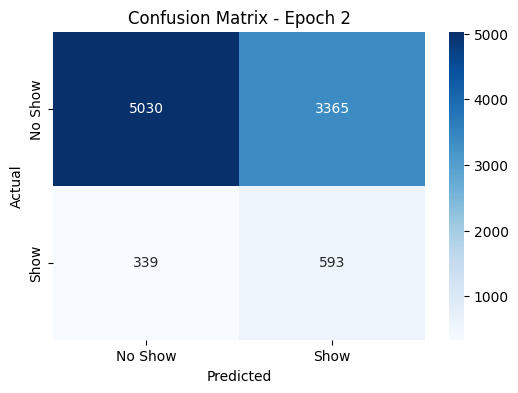

              precision    recall  f1-score   support

         0.0       0.94      0.60      0.73      8395
         1.0       0.15      0.64      0.24       932

    accuracy                           0.60      9327
   macro avg       0.54      0.62      0.49      9327
weighted avg       0.86      0.60      0.68      9327

Epoch 2/10
Train Loss: 1.1826, Val Loss: 0.8951
Val Metrics: {'precision': 0.14982314300151592, 'recall': 0.6362660944206009, 'f1': 0.2425357873210634, 'accuracy': np.float64(0.6028733783638898), 'roc_auc': np.float64(0.6640103576878738), 'true_positives': np.int64(593), 'false_positives': np.int64(3365), 'true_negatives': np.int64(5030), 'false_negatives': np.int64(339)}


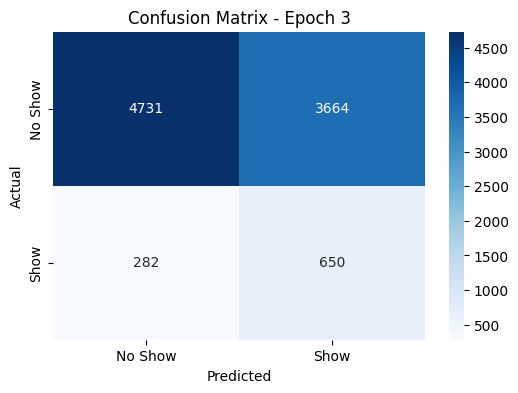

              precision    recall  f1-score   support

         0.0       0.94      0.56      0.71      8395
         1.0       0.15      0.70      0.25       932

    accuracy                           0.58      9327
   macro avg       0.55      0.63      0.48      9327
weighted avg       0.86      0.58      0.66      9327

Epoch 3/10
Train Loss: 1.1685, Val Loss: 0.9072
Val Metrics: {'precision': 0.15067222994900326, 'recall': 0.6974248927038627, 'f1': 0.24780785360274496, 'accuracy': np.float64(0.5769272006004074), 'roc_auc': np.float64(0.673511337987306), 'true_positives': np.int64(650), 'false_positives': np.int64(3664), 'true_negatives': np.int64(4731), 'false_negatives': np.int64(282)}


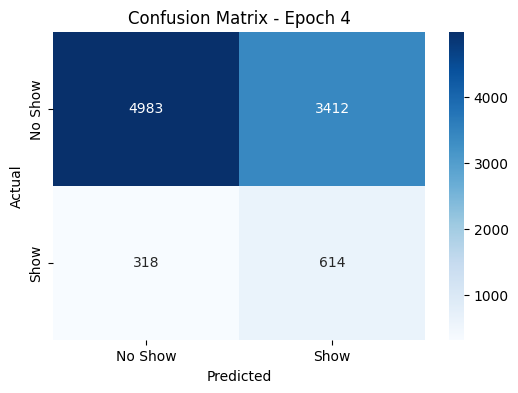

              precision    recall  f1-score   support

         0.0       0.94      0.59      0.73      8395
         1.0       0.15      0.66      0.25       932

    accuracy                           0.60      9327
   macro avg       0.55      0.63      0.49      9327
weighted avg       0.86      0.60      0.68      9327

Epoch 4/10
Train Loss: 1.1537, Val Loss: 0.8958
Val Metrics: {'precision': 0.15250869349230006, 'recall': 0.6587982832618026, 'f1': 0.24768051633723276, 'accuracy': np.float64(0.6000857724884743), 'roc_auc': np.float64(0.6764262909406017), 'true_positives': np.int64(614), 'false_positives': np.int64(3412), 'true_negatives': np.int64(4983), 'false_negatives': np.int64(318)}


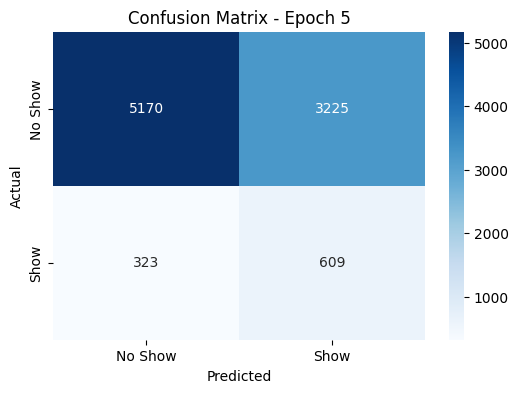

              precision    recall  f1-score   support

         0.0       0.94      0.62      0.74      8395
         1.0       0.16      0.65      0.26       932

    accuracy                           0.62      9327
   macro avg       0.55      0.63      0.50      9327
weighted avg       0.86      0.62      0.70      9327

Epoch 5/10
Train Loss: 1.1463, Val Loss: 0.8976
Val Metrics: {'precision': 0.15884194053208137, 'recall': 0.6534334763948498, 'f1': 0.2555602182123374, 'accuracy': np.float64(0.6195990136163826), 'roc_auc': np.float64(0.6849057532201622), 'true_positives': np.int64(609), 'false_positives': np.int64(3225), 'true_negatives': np.int64(5170), 'false_negatives': np.int64(323)}


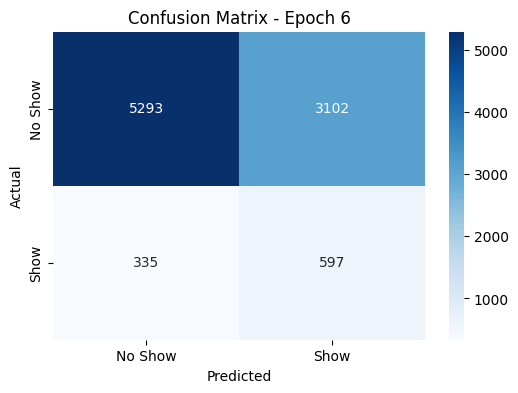

              precision    recall  f1-score   support

         0.0       0.94      0.63      0.75      8395
         1.0       0.16      0.64      0.26       932

    accuracy                           0.63      9327
   macro avg       0.55      0.64      0.51      9327
weighted avg       0.86      0.63      0.71      9327

Epoch 6/10
Train Loss: 1.1339, Val Loss: 0.8885
Val Metrics: {'precision': 0.16139497161394972, 'recall': 0.6405579399141631, 'f1': 0.25782768300583025, 'accuracy': np.float64(0.6314999463921948), 'roc_auc': np.float64(0.6922152466596968), 'true_positives': np.int64(597), 'false_positives': np.int64(3102), 'true_negatives': np.int64(5293), 'false_negatives': np.int64(335)}


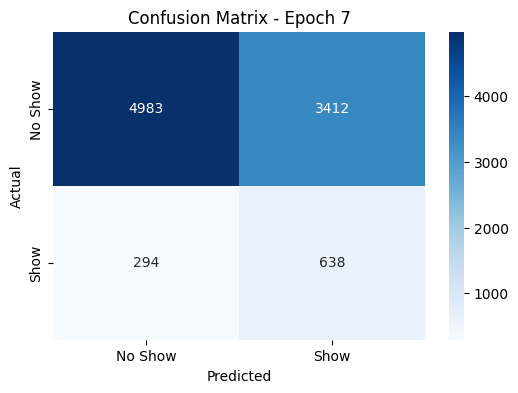

              precision    recall  f1-score   support

         0.0       0.94      0.59      0.73      8395
         1.0       0.16      0.68      0.26       932

    accuracy                           0.60      9327
   macro avg       0.55      0.64      0.49      9327
weighted avg       0.87      0.60      0.68      9327

Epoch 7/10
Train Loss: 1.1262, Val Loss: 0.8823
Val Metrics: {'precision': 0.15753086419753087, 'recall': 0.6845493562231759, 'f1': 0.25612203934162986, 'accuracy': np.float64(0.602658947142704), 'roc_auc': np.float64(0.6916510952002393), 'true_positives': np.int64(638), 'false_positives': np.int64(3412), 'true_negatives': np.int64(4983), 'false_negatives': np.int64(294)}


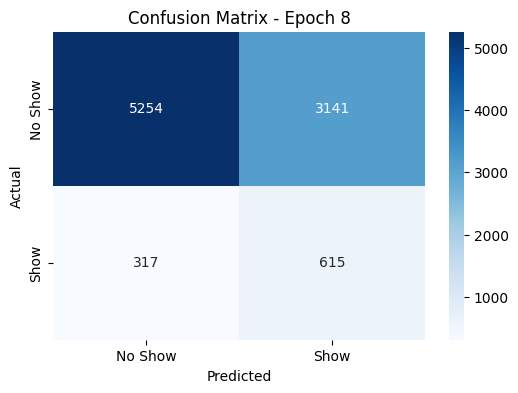

              precision    recall  f1-score   support

         0.0       0.94      0.63      0.75      8395
         1.0       0.16      0.66      0.26       932

    accuracy                           0.63      9327
   macro avg       0.55      0.64      0.51      9327
weighted avg       0.87      0.63      0.70      9327

Epoch 8/10
Train Loss: 1.1230, Val Loss: 0.8809
Val Metrics: {'precision': 0.16373801916932906, 'recall': 0.6598712446351931, 'f1': 0.2623720136518771, 'accuracy': np.float64(0.6292484185697438), 'roc_auc': np.float64(0.694148558180196), 'true_positives': np.int64(615), 'false_positives': np.int64(3141), 'true_negatives': np.int64(5254), 'false_negatives': np.int64(317)}


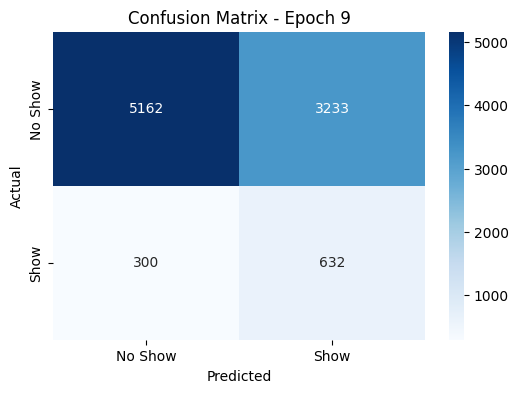

              precision    recall  f1-score   support

         0.0       0.95      0.61      0.75      8395
         1.0       0.16      0.68      0.26       932

    accuracy                           0.62      9327
   macro avg       0.55      0.65      0.50      9327
weighted avg       0.87      0.62      0.70      9327

Epoch 9/10
Train Loss: 1.1096, Val Loss: 0.8922
Val Metrics: {'precision': 0.16351875808538163, 'recall': 0.6781115879828327, 'f1': 0.26349801959558056, 'accuracy': np.float64(0.621207247775276), 'roc_auc': np.float64(0.6967748532107043), 'true_positives': np.int64(632), 'false_positives': np.int64(3233), 'true_negatives': np.int64(5162), 'false_negatives': np.int64(300)}


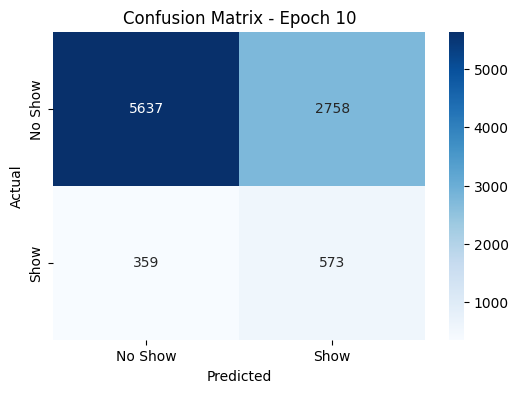

              precision    recall  f1-score   support

         0.0       0.94      0.67      0.78      8395
         1.0       0.17      0.61      0.27       932

    accuracy                           0.67      9327
   macro avg       0.56      0.64      0.53      9327
weighted avg       0.86      0.67      0.73      9327

Epoch 10/10
Train Loss: 1.0982, Val Loss: 0.8685
Val Metrics: {'precision': 0.172020414290003, 'recall': 0.6148068669527897, 'f1': 0.26882477128782545, 'accuracy': np.float64(0.6658089417819234), 'roc_auc': np.float64(0.690975621601863), 'true_positives': np.int64(573), 'false_positives': np.int64(2758), 'true_negatives': np.int64(5637), 'false_negatives': np.int64(359)}

Evaluating different thresholds...
Best threshold based on cost savings: 0.4500000000000001


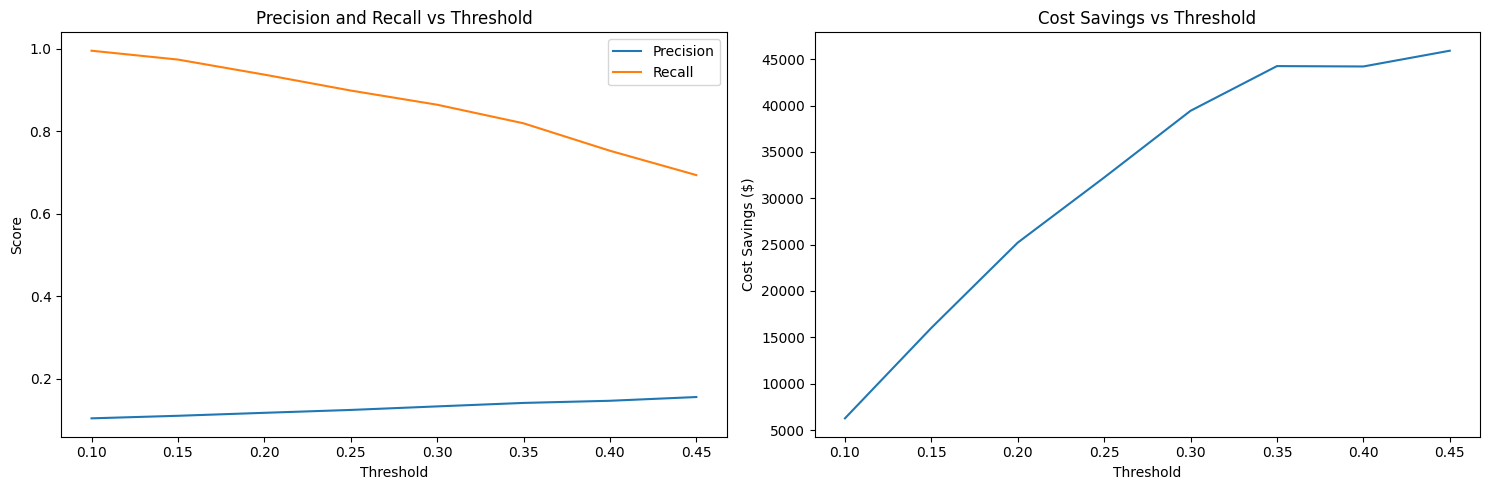


Best threshold: 0.450
Cost savings: $45920.00
Precision: 0.155
Recall: 0.693


best_cost_savings,▁
best_precision,▁
best_recall,▁
best_threshold,▁
epoch,▁▂▃▃▄▅▆▆▇█
learning_rate,▁▁▁▁▁▁▁▁▁▁
train_loss,█▆▅▄▄▃▃▂▂▁
val_accuracy,▃▃▁▃▄▅▃▅▄█
val_f1,▁▂▃▃▅▅▅▇▇█
val_loss,█▆█▆▆▅▃▃▅▁
val_precision,▁▂▂▃▄▅▄▆▆█


In [3]:
from src.training.nn_trainer import run_nn_pipeline
# 定義不同的配置進行實驗
configs = [
    {
        "learning_rate": 0.001,
        "weight_decay": 0.01,
        "batch_size": 64,
        "hidden_dims": [512, 256, 128, 64],
        "dropout_rates": [0.5, 0.4, 0.3, 0.2],
        "epochs": 10,
        "patience": 15,
        "pos_weight": 8395/932  # 添加這個參數
    },
    # {
    #     "learning_rate": 0.0005,
    #     "weight_decay": 0.02,
    #     "batch_size": 128,
    #     "hidden_dims": [512, 256, 128],
    #     "dropout_rates": [0.5, 0.4, 0.3],
    #     "epochs": 30,
    #     "patience": 10,
    #     "pos_weight": 8395/932  # 添加這個參數
    # }
]
numerical_features = [
        'age', 
        'max_temp_day', 
        'average_temp_day', 
        'average_rain_day',
        'max_rain_day'
    ]

# 運行實驗
for config in configs:
    model, best_threshold, final_metrics = run_nn_pipeline(X, y, numerical_features, config)